In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Datensatz laden (mit Semikolon als Trenner)
df = pd.read_csv("Daten LB.csv", sep=';')

# 3.1 Teilen Sie Ihren Datensatz in einen test- und einen train-Satz ein
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
#Test
print(f"Datensatz erfolgreich geteilt: {len(train_df)} Trainingsdaten, {len(test_df)} Testdaten.")

Datensatz erfolgreich geteilt: 6992 Trainingsdaten, 1748 Testdaten.


In [12]:
#3.2
y_ftr_train = train_df["FTR"]
y_ftr_test = test_df["FTR"]

y_goals_train = train_df[["FTHG", "FTAG"]]
y_goals_test = test_df[["FTHG", "FTAG"]]

drop_cols = ["FTR", "FTHG", "FTAG"]

X_train = train_df.drop(columns=drop_cols)
X_test = test_df.drop(columns=drop_cols)

X_train = X_train.select_dtypes(include=["number"])
X_test = X_test.select_dtypes(include=["number"])

#Modelle erstellen

# Klassifikation (Spielausgang)
model_ftr = RandomForestClassifier(n_estimators=10, random_state=42)
model_ftr.fit(X_train, y_ftr_train)

# Regression (Tore)
model_goals = RandomForestRegressor(n_estimators=10, random_state=42)
model_goals.fit(X_train, y_goals_train)

print("Modelle wurden erfolgreich auf den Trainingsdaten berechnet.")

Modelle wurden erfolgreich auf den Trainingsdaten berechnet.


In [15]:
#3.3
import numpy as np

random_indices = np.random.choice(X_test.index, size=10, replace=False)

for idx in random_indices:
    game_features = X_test.loc[[idx]]
    
    real_info = df.loc[idx]
    
    pred_ftr = model_ftr.predict(game_features)[0]
    prob_ftr = model_ftr.predict_proba(game_features)[0]
    pred_goals = model_goals.predict(game_features)[0]

#Überprüfung der Vorhersagen
    print(f"Spiel: {real_info['HomeTeam']} vs {real_info['AwayTeam']}")
    print(f"  Tatsächlich: {real_info['FTR']} (Tore: {real_info['FTHG']} : {real_info['FTAG']})")
    print(f"  Vorhersage:  {pred_ftr} (Erwartete Tore: {pred_goals[0]:.1f} : {pred_goals[1]:.1f})")
    print(f"  Siegchancen: Heim {prob_ftr[2]:.1%}, Remis {prob_ftr[1]:.1%}, Gast {prob_ftr[0]:.1%}")
    print("-" * 50)

    correct = 0

for idx in random_indices:
    game_features = X_test.loc[[idx]]
    real_info = df.loc[idx]

    pred_ftr = model_ftr.predict(game_features)[0]

    if pred_ftr == real_info["FTR"]:
        correct += 1

accuracy = correct / len(random_indices)

print(f"Vorhersage Tore richtig: {accuracy:.2%}")

correct_prob = 0

for idx in random_indices:
    game_features = X_test.loc[[idx]]
    real_info = df.loc[idx]

    prob = model_ftr.predict_proba(game_features)[0]
    pred_class = model_ftr.predict(game_features)[0]

    # richtige Klasse finden
    classes = model_ftr.classes_
    true_index = list(classes).index(real_info["FTR"])

    # war die höchste Wahrscheinlichkeit korrekt?
    if prob.argmax() == true_index:
        correct_prob += 1

prob_accuracy = correct_prob / len(random_indices)

print(f"H/R/G Vorhersage Richtig: {prob_accuracy:.2%}")

Spiel: Brighton vs Liverpool
  Tatsächlich: H (Tore: 3 : 0)
  Vorhersage:  D (Erwartete Tore: 1.1 : 0.3)
  Siegchancen: Heim 50.0%, Remis 50.0%, Gast 0.0%
--------------------------------------------------
Spiel: Liverpool vs Chelsea
  Tatsächlich: A (Tore: 0 : 2)
  Vorhersage:  A (Erwartete Tore: 1.5 : 1.9)
  Siegchancen: Heim 20.0%, Remis 40.0%, Gast 40.0%
--------------------------------------------------
Spiel: Newcastle vs Bolton
  Tatsächlich: H (Tore: 1 : 0)
  Vorhersage:  H (Erwartete Tore: 2.1 : 0.5)
  Siegchancen: Heim 60.0%, Remis 20.0%, Gast 20.0%
--------------------------------------------------
Spiel: Newcastle vs QPR
  Tatsächlich: H (Tore: 1 : 0)
  Vorhersage:  A (Erwartete Tore: 1.2 : 1.3)
  Siegchancen: Heim 40.0%, Remis 20.0%, Gast 40.0%
--------------------------------------------------
Spiel: QPR vs Southampton
  Tatsächlich: A (Tore: 0 : 1)
  Vorhersage:  A (Erwartete Tore: 0.2 : 0.6)
  Siegchancen: Heim 0.0%, Remis 40.0%, Gast 60.0%
-----------------------------

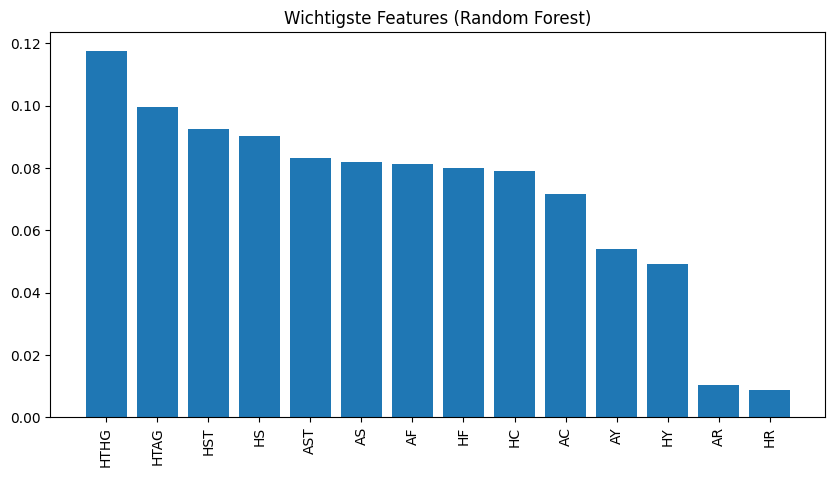

HTHG 0.11770234685333605
HTAG 0.09948244803242014
HST 0.09243142683910706
HS 0.09039538563326159
AST 0.08328897614180604


In [16]:
import matplotlib.pyplot as plt

# Feature Importance aus dem Klassifikationsmodell
importances = model_ftr.feature_importances_
feature_names = X_train.columns

# sortieren
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,5))
plt.title("Wichtigste Features (Random Forest)")
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), feature_names[indices], rotation=90)
plt.show()

# Top 5 Features ausgeben
for i in indices[:5]:
    print(feature_names[i], importances[i])

In [17]:
from sklearn.metrics import accuracy_score

y_pred = model_ftr.predict(X_test)

accuracy = accuracy_score(y_ftr_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.6104118993135011


In [18]:
from sklearn.metrics import mean_absolute_error

y_pred_goals = model_goals.predict(X_test)

mae = mean_absolute_error(y_goals_test, y_pred_goals)

print("MAE:", mae)

MAE: 0.698512585812357


In [21]:
from sklearn.metrics import confusion_matrix

# =========================
# 1. Vorhersagen erstellen
# =========================
y_pred = model_ftr.predict(X_test)

# =========================
# 2. Problem lösen: Multi-Class → Binary (Heimsieg vs Rest)
# =========================
y_test_bin = (y_ftr_test == "H")
y_pred_bin = (y_pred == "H")

# =========================
# 3. Wahrheitsmatrix
# =========================
cm = confusion_matrix(y_test_bin, y_pred_bin)

tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix:")
print(cm)

# =========================
# 4. Sensitivität (Recall)
# =========================
sensitivity = tp / (tp + fn)

print("\nSensitivität:", sensitivity)

# =========================
# 5. Spezifität
# =========================
specificity = tn / (tn + fp)

print("Spezifität:", specificity)

Confusion Matrix:
[[694 231]
 [226 597]]

Sensitivität: 0.7253948967193196
Spezifität: 0.7502702702702703


Das Modell ist Okay aber lange nicht Perfekt, da einfach zu viele Daten fehlen (z.B. Verletzte Spieler) oder auch Sachen die nicht berechnet werden können (z.B. Verletzungen während des Spiels). Eine Genauigkeit zwischen 60% und 70% ist viel höher als von mir erwartet, da eben viele wichtige Daten fehlen. Dies zeigt, dass die vorhandenen Daten bereits eine gewisse Vorhersagekraft besitzen, auch wenn die Qualität und Vollständigkeit der Eingabedaten noch klar verbessert werden könnten.